In [23]:
%pip install matplotlib

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ---------------------------------------- 0.0/7.8 MB ? eta -:--:--
   --------- ------------------------------ 1.8/7.8 MB 9.1 MB/s eta 0:00:01
   ------------------ --------------------- 3.7/7.8 MB 9.1 MB/s eta 0:00:01
   -------------------------------- ------- 6.3/7.8 MB 10.7 MB/s eta 0:00:01
   ---------------------------------------- 7.8/7.8 MB 11.3 MB/s  0:00:00
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 1.5/1.5 MB 16.5 MB/s  0:00:00
   ---------------------------------------- 0.0/7.0 MB ? eta -:--:--
   --------------------- ------------------ 3.7/7.0 MB 18.2 MB/s eta 0:00:01
   ---------------------------------------  6.8/7.0 MB 18.3 MB/s eta 0:00:01
   ---------------------------------------- 7.0/7.0 MB 16.6 MB/s  0:00:00

   ---------------------------------------- 0/8 [pyparsing]
   ----- -

In [28]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [17]:
import numpy as np
from distancematrix.generator.euclidean import Euclidean
from distancematrix.consumer.radius_profile import RadiusProfile
from distancematrix.consumer.matrix_profile_lr import MatrixProfileLR
from distancematrix.generator.znorm_euclidean import ZNormEuclidean
from distancematrix.consumer.multidimensional_matrix_profile_lr import MultidimensionalMatrixProfileLR
from distancematrix.consumer.matrix_profile_lr import MatrixProfileLR
from distancematrix.calculator import AnytimeCalculator



In [18]:
VIRTUOSO_URL = "http://localhost:8890/sparql"
GRAPH_URI    = "http://example.com/Gent-Terneuzen"
USERNAME     = "dba"
PASSWORD     = "dba"
AUTH         = (USERNAME, PASSWORD)
params  = {'graph': GRAPH_URI}
headers = {'Accept': 'text/turtle'}

# Identifying unique sensors


In [19]:
sensor_set = set()

sensor_query = f"""
    PREFIX sosa: <http://www.w3.org/ns/sosa/>
    SELECT DISTINCT ?sensor
    WHERE {{
        GRAPH <{GRAPH_URI}> {{
            ?obs a sosa:Observation ;
                 sosa:madeBySensor ?sensor .
        }}
    }}
    """
res = requests.get(VIRTUOSO_URL, params={'query': sensor_query, 'format': 'application/sparql-results+json'})
if res.status_code != 200:
    print(f"Error: {res.status_code}")
    print("Response:", res.text)
else:
    print("Unique sensors identified successfully!")

data     = res.json()
bindings = data['results']['bindings']
for row in bindings:
    sensor_set.add(row['sensor']['value'])

print(f"Added {len(sensor_set)} unique sensors to the set.")
print("Sensors:", sensor_set)

Unique sensors identified successfully!
Added 4 unique sensors to the set.
Sensors: {'http://example.com/waterinfo/289423042', 'http://example.com/waterinfo/289441042', 'http://example.com/waterinfo/289435042', 'http://example.com/waterinfo/289429042'}


# Reframe the data

In [20]:
final_df = pd.DataFrame()
print("Fetching and pivoting sensor data...")

for sensor_uri in sensor_set:
    column_name = sensor_uri.split('/')[-1]
    query = f"""
        PREFIX sosa: <http://www.w3.org/ns/sosa/>
        PREFIX ex: <http://example.com/attributes/>
        SELECT ?time ?value ?unixtime
        WHERE {{
            GRAPH <{GRAPH_URI}> {{
                ?obs a sosa:Observation ;
                    sosa:resultTime ?time ;
                    sosa:hasSimpleResult ?value ;
                    ex:unixTimestamp ?unixtime ;
                    sosa:madeBySensor <{sensor_uri}> .
            }}
        }}
    """
    res = requests.get(VIRTUOSO_URL, params={'query': query, 'format': 'application/sparql-results+json'})
    if res.status_code == 200:
        bindings = res.json()['results']['bindings']
        temp_data = [
            {'time': row['time']['value'], column_name: float(row['value']['value']),
             'unixtime': int(row['unixtime']['value'])}
            for row in bindings
        ]
        temp_df = pd.DataFrame(temp_data)
        if not temp_df.empty:
            temp_df['time'] = pd.to_datetime(temp_df['time'])
            if final_df.empty:
                final_df = temp_df
            else:
                final_df = pd.merge(final_df, temp_df, on=['time', 'unixtime'], how='outer')
            print(f"Added column for sensor: {column_name}")

final_df = final_df.sort_values('time').set_index('time')
print("Finished!")
print(final_df.head())

Fetching and pivoting sensor data...
Added column for sensor: 289423042
Added column for sensor: 289441042
Added column for sensor: 289435042
Added column for sensor: 289429042
Finished!
                           289423042    unixtime  289441042  289435042  \
time                                                                     
2021-03-03 23:15:00+00:00        NaN  1614813300    4797.72    3606.54   
2021-03-03 23:30:00+00:00        NaN  1614814200    4717.80        NaN   
2021-03-03 23:45:00+00:00     902.27  1614815100    4745.36    3556.45   
2021-03-04 00:00:00+00:00        NaN  1614816000        NaN        NaN   
2021-03-04 00:15:00+00:00     901.96  1614816900        NaN        NaN   

                           289429042  
time                                  
2021-03-03 23:15:00+00:00    1605.77  
2021-03-03 23:30:00+00:00        NaN  
2021-03-03 23:45:00+00:00    1602.34  
2021-03-04 00:00:00+00:00    1611.26  
2021-03-04 00:15:00+00:00    1614.24  


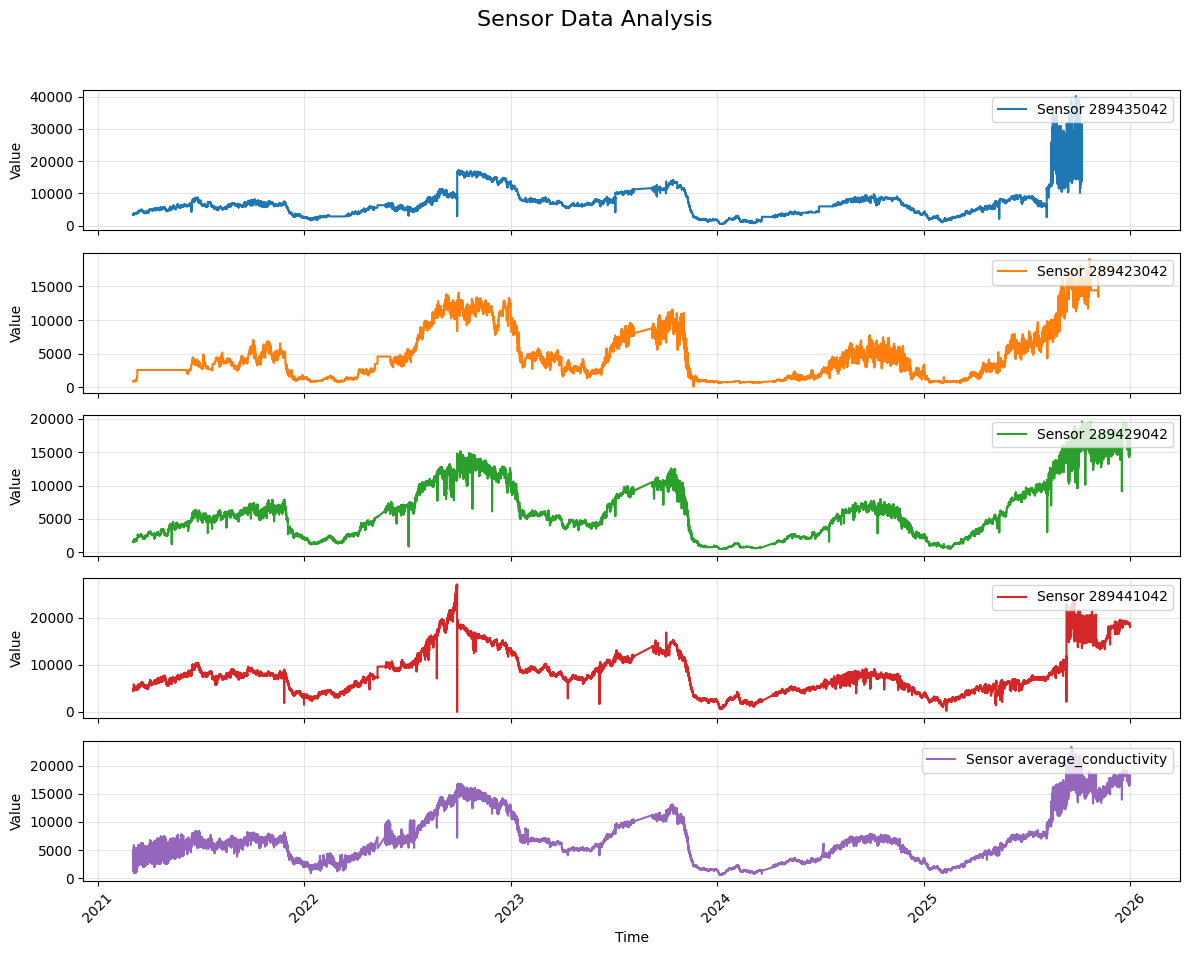

In [25]:
fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(12, 10), sharex=True)

sensors = ['289435042', '289423042', '289429042', '289441042']
colors  = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728','#9467bd']
final_df['average_conductivity'] = final_df[sensors].mean(axis=1)
final_df = final_df.bfill()
sensors_with_avg = sensors + ['average_conductivity']

for i, sensor in enumerate(sensors_with_avg):
    ax = axes[i]
    ax.plot(final_df.index, final_df[sensor], label=f"Sensor {sensor}", color=colors[i])
    ax.set_ylabel("Value")
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

plt.suptitle("Sensor Data Analysis", fontsize=16)
plt.xlabel("Time")
plt.xticks(rotation=45)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [29]:
colors   = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
m        = 96 * 7        # 1-week window at 15-min intervals
PARTIAL  = 0.5           # fraction of diagonals to compute (0.25 = fast/approx, 1.0 = exact)
CACHE    = "distmat_cache.npz"

# ── Prepare data: shape (n_sensors, n_timepoints) ──────────────────────────────
T = np.array([
    final_df[s].interpolate(method='linear').bfill().ffill().values
    for s in sensors
])
print(f"Data shape: {T.shape}  |  window m={m}  |  profile length={T.shape[1]-m+1}")

# ── Load cache or compute ──────────────────────────────────────────────────────
if os.path.exists(CACHE):
    print(f"Loading cached results")
    cache = np.load(CACHE)
    mmp   = cache["mmp"]           # shape: (n_dims, profile_length)
    print(f"   mmp shape: {mmp.shape}")
else:
    print(f"Computing AnytimeCalculator at partial={PARTIAL}")

    calc     = AnytimeCalculator(m, T)
    generators, consumers_mmp = [], []

    # One ZNormEuclidean generator per sensor channel
    for ch in range(len(sensors)):
        calc.add_generator(ch, ZNormEuclidean())

    # One consumer that combines all channels
    cons_mmp = calc.add_consumer(list(range(len(sensors))), MultidimensionalMatrixProfileLR())


    calc.calculate_diagonals(partial=PARTIAL)

    mmp = cons_mmp.md_matrix_profile()   # shape: (n_dims, profile_length)
    np.savez(CACHE, mmp=mmp)
    print(f"Saved.  mmp shape: {mmp.shape}")

# ── Find motifs & discords from the all-dimensions profile ─────────────────────
aggregate_profile = mmp[-1]   # last row = best combination of all 4 dims

def find_peaks(profile, top_n=3, exclusion_zone=None, ascending=True):
    ez = exclusion_zone or m
    found = []
    for idx in np.argsort(profile)[::1 if ascending else -1]:
        if len(found) >= top_n:
            break
        if all(abs(idx - f) > ez for f in found):
            found.append(int(idx))
    return found

motifs   = find_peaks(aggregate_profile, top_n=3, ascending=True)
discords = find_peaks(aggregate_profile, top_n=3, ascending=False)
print(f"\nTop motif indices   : {motifs}")
print(f"Top discord indices : {discords}")

Data shape: (4, 160808)  |  window m=672  |  profile length=160137
Computing AnytimeCalculator at partial=0.5
Saved.  mmp shape: (4, 160137)

Top motif indices   : [88272, 39732, 100202]
Top discord indices : [52103, 152026, 43590]


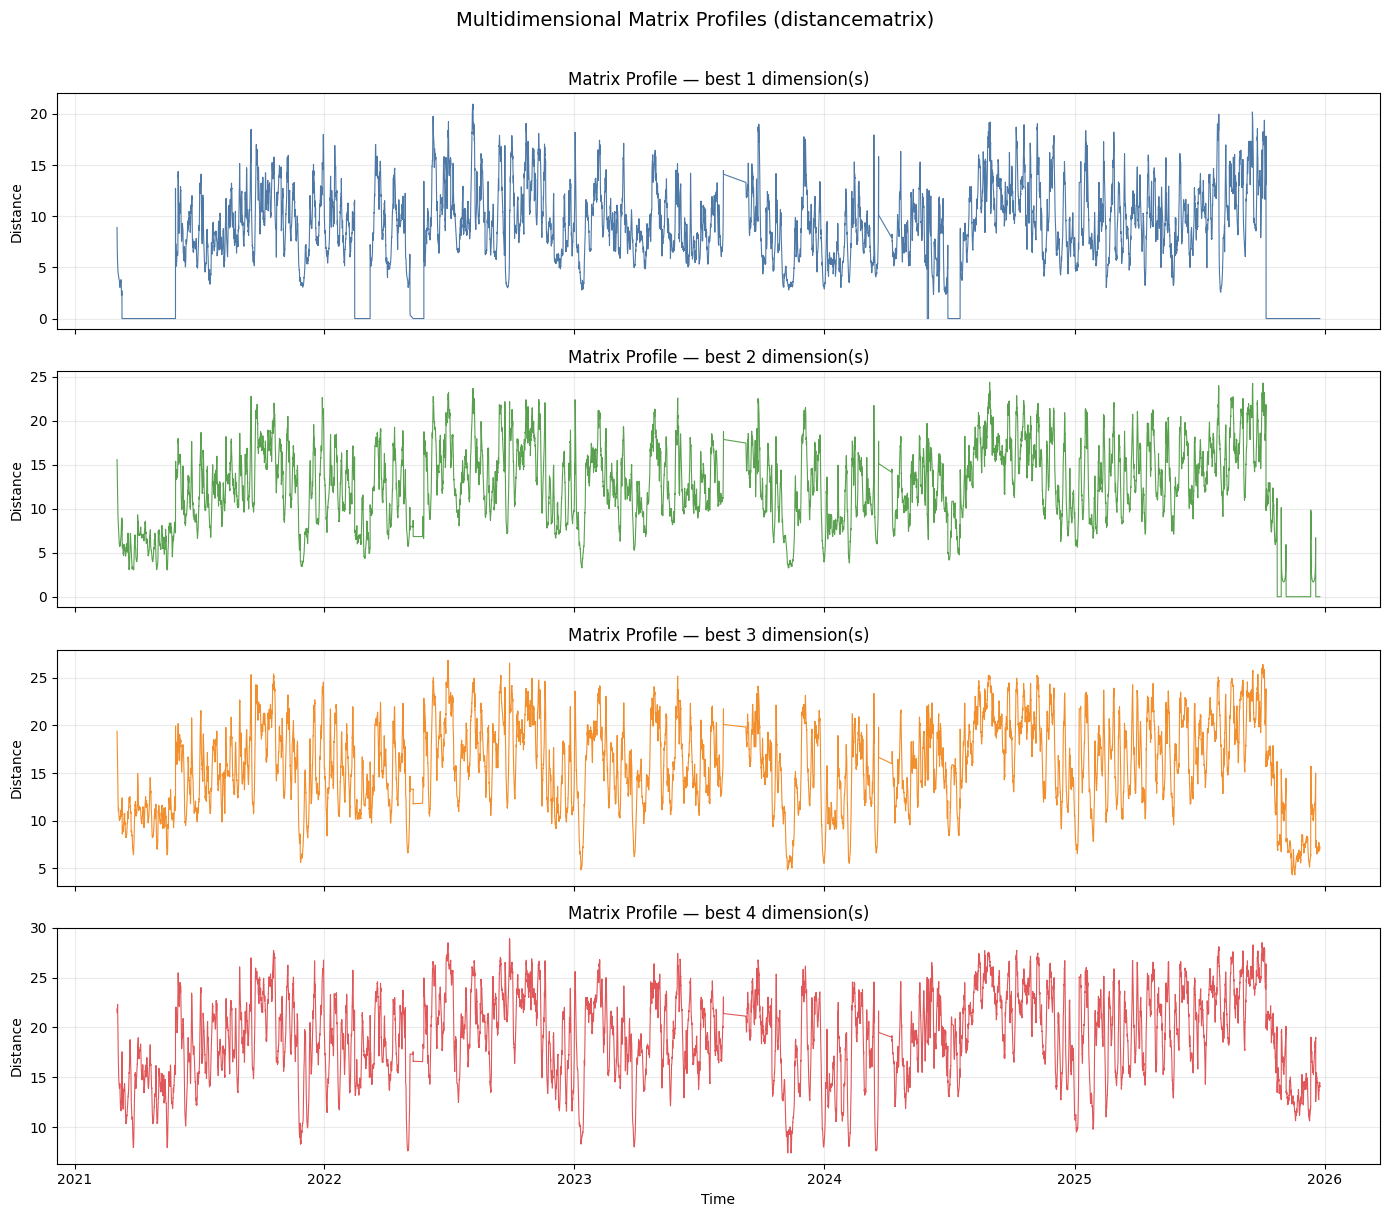

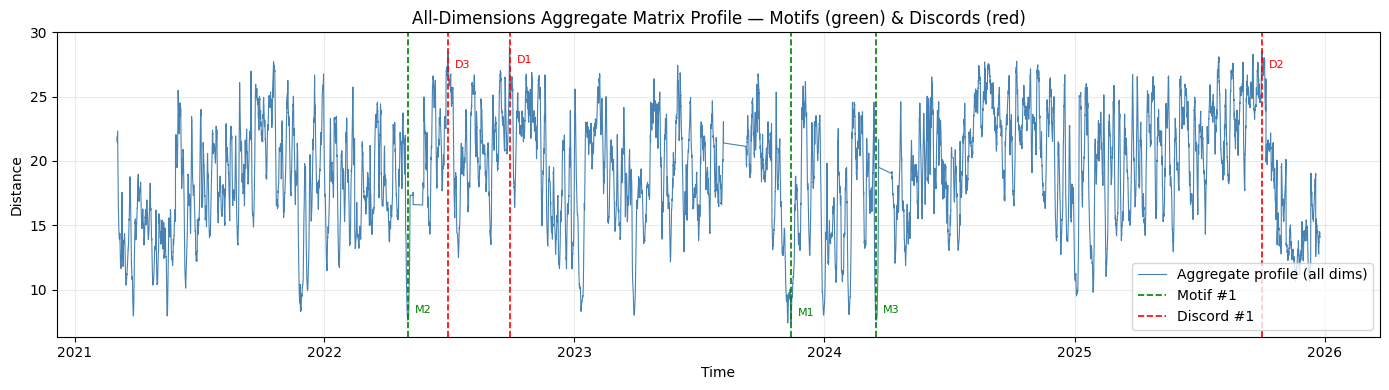

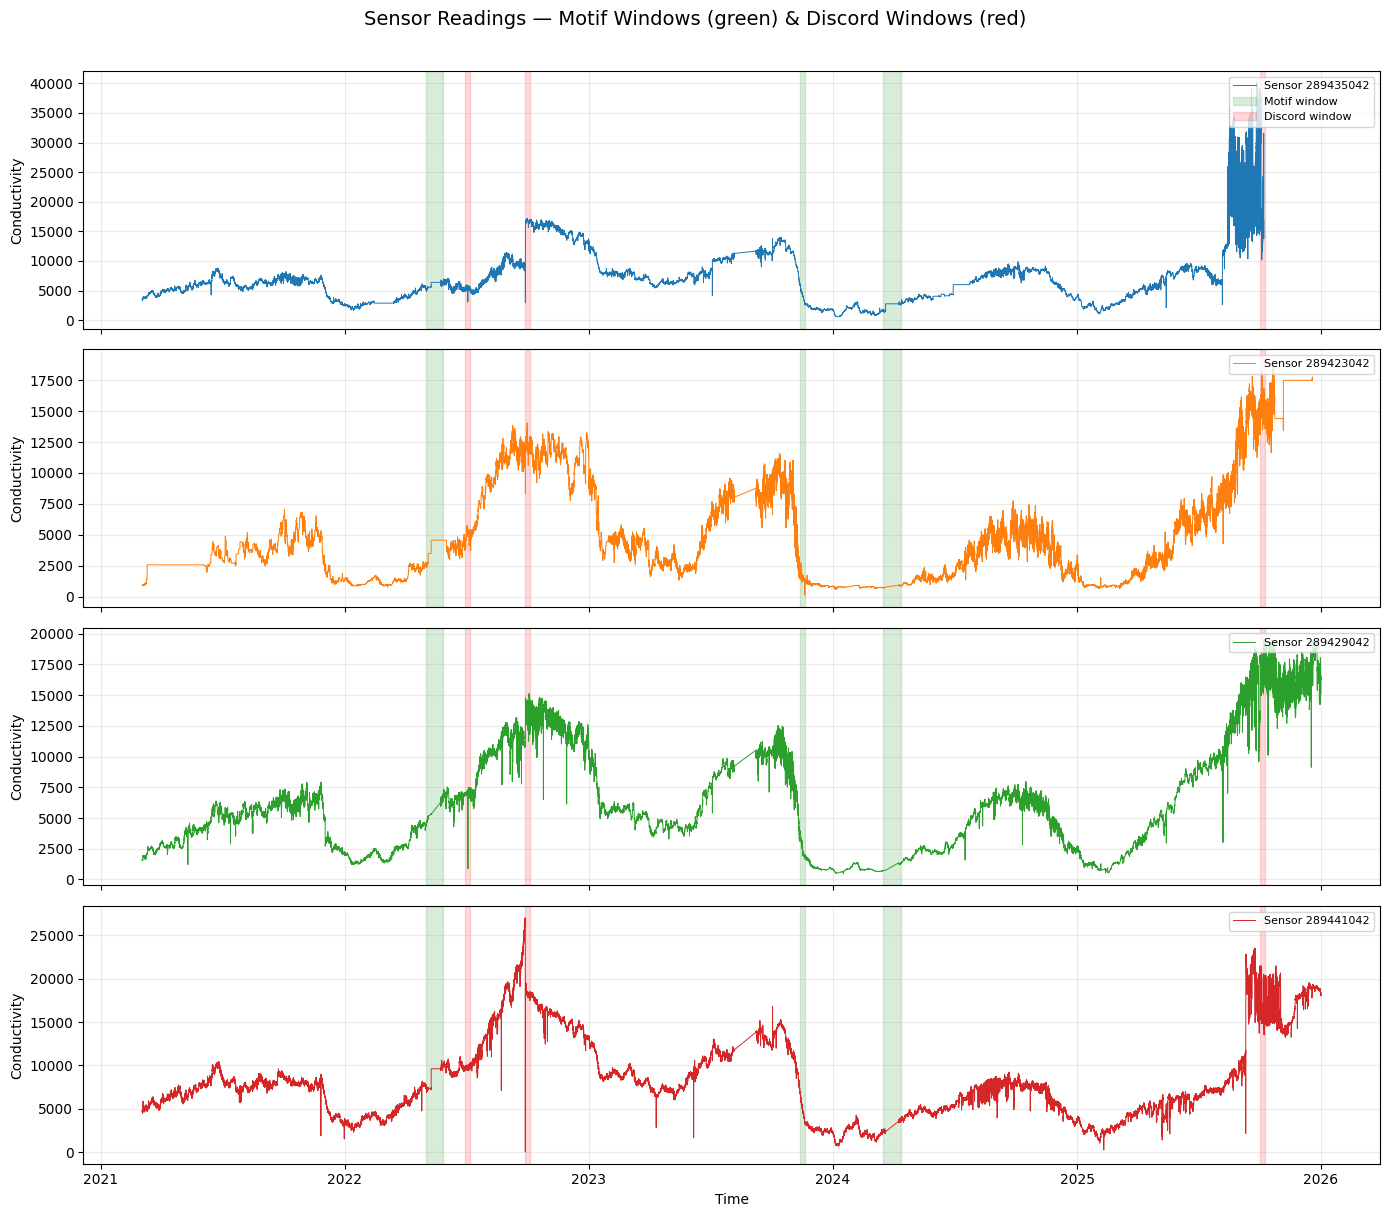

In [30]:
time_index = final_df.index
profile_index = time_index[: len(aggregate_profile)]   # profile is m-1 shorter than T

# ── Figure 1: Per-dimension matrix profiles ────────────────────────────────────
n_dims = mmp.shape[0]
fig, axes = plt.subplots(n_dims, 1, figsize=(14, 3 * n_dims), sharex=True)
dim_colors = ['#4e79a7', '#59a14f', '#f28e2b', '#e15759']

for k in range(n_dims):
    ax = axes[k]
    ax.plot(profile_index, mmp[k], color=dim_colors[k], linewidth=0.8)
    ax.set_ylabel("Distance")
    ax.set_title(f"Matrix Profile — best {k+1} dimension(s)")
    ax.grid(True, alpha=0.25)

axes[-1].set_xlabel("Time")
plt.suptitle("Multidimensional Matrix Profiles (distancematrix)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# ── Figure 2: Aggregate profile with motif & discord annotations ───────────────
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(profile_index, aggregate_profile, color='steelblue', linewidth=0.8, label="Aggregate profile (all dims)")

for rank, idx in enumerate(motifs):
    ax.axvline(profile_index[idx], color='green', linestyle='--', linewidth=1.2,
               label=f"Motif #{rank+1}" if rank == 0 else "_")
    ax.annotate(f"M{rank+1}", xy=(profile_index[idx], aggregate_profile[idx]),
                xytext=(5, 5), textcoords='offset points', color='green', fontsize=8)

for rank, idx in enumerate(discords):
    ax.axvline(profile_index[idx], color='red', linestyle='--', linewidth=1.2,
               label=f"Discord #{rank+1}" if rank == 0 else "_")
    ax.annotate(f"D{rank+1}", xy=(profile_index[idx], aggregate_profile[idx]),
                xytext=(5, -12), textcoords='offset points', color='red', fontsize=8)

ax.set_ylabel("Distance")
ax.set_xlabel("Time")
ax.set_title("All-Dimensions Aggregate Matrix Profile — Motifs (green) & Discords (red)")
ax.legend()
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

# ── Figure 3: Raw sensor signals with motif/discord windows highlighted ─────────
fig, axes = plt.subplots(len(sensors), 1, figsize=(14, 3 * len(sensors)), sharex=True)

for i, sensor in enumerate(sensors):
    ax = axes[i]
    ax.plot(time_index, final_df[sensor].values, color=colors[i], linewidth=0.7, label=f"Sensor {sensor}")

    for rank, idx in enumerate(motifs):
        start, end = time_index[idx], time_index[min(idx + m - 1, len(time_index) - 1)]
        ax.axvspan(start, end, color='green', alpha=0.15,
                   label="Motif window" if rank == 0 and i == 0 else "_")

    for rank, idx in enumerate(discords):
        start, end = time_index[idx], time_index[min(idx + m - 1, len(time_index) - 1)]
        ax.axvspan(start, end, color='red', alpha=0.15,
                   label="Discord window" if rank == 0 and i == 0 else "_")

    ax.set_ylabel("Conductivity")
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.25)

axes[0].legend(loc='upper right', fontsize=8)
axes[-1].set_xlabel("Time")
plt.suptitle("Sensor Readings — Motif Windows (green) & Discord Windows (red)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()